# Async programming

Asynchronous programming is a programming paradigm that allows us to write code that can run concurrently without blocking the main thread.\
It is particularly useful for I/O-bound tasks, such as network requests or file operations,\
where the program can continue executing other tasks while waiting for the I/O operation to complete.\

First what happens when we execute a synchronous code?\
When we execute a synchronous code, the program will block and wait for each instruction to complete before moving on to the next one.\
For example, if we have a function that takes a long time to execute, the program will block and wait for that function to complete before moving on to the next instruction:
```python
import time

def slow_task() -> str:
    print("Starting slow task")
    time.sleep(3)
    print("Slow task completed")
    return "slow"

result = slow_task()
print(f"Result: {result}")
```
This can lead to a poor user experience, as the program may become unresponsive while waiting for the long-running function to complete.

On the other hand, with asynchronous programming, we can write code that can run concurrently without blocking the main thread.\
This allows us to write more efficient and responsive programs, as we can continue executing other tasks while waiting for the long-running function to complete.\
We will start with a simple example of an asynchronous function that simulates a long-running task:
```python
import time

async def slow_task() -> str:
    print("Starting slow task")
    time.sleep(5)
    print("Slow task completed")
    return "slow"

result = slow_task()
print(f"Result: {result}")  # Output: Result: <coroutine object slow_task at 0x00000224E7073040>
```
This code only return a Coroutine object, and it does not execute the function.\
Because coroutines are not executed until they are awaited, we need to use the `await` keyword to execute the function and wait for it to complete\
We will see how to use `await` in next sections,\
but for now, we can see that the function is not executed and the program continues to execute the next instruction without waiting for the slow task to complete.

In Python, we can use the `asyncio` library to write asynchronous code.\
This library provides a set of tools to manage asynchronous tasks, such as creating and running coroutines, managing event loops, and handling exceptions.\
In this notebook, we will explore the basics of asynchronous programming in Python using the `asyncio` library.

## Asyncio

First of all, we need to understand the difference between asynchronous and synchronous programming.\
A synchronous code is one where each instruction waits for the previous one to execute, while asynchronous code does not wait for deferred instructions and continues with its execution.\
It is basically what is defined as parallel programming.\
Parallelism consists of performing multiple operations at the same time.

### Basics Methods

In this section, we will explore the basic methods provided by the `asyncio` library to manage asynchronous tasks.\
We will cover the following methods:
- `asyncio.run()`
- `await`
- `asyncio.gather()`

#### Run
This is the main method to execute asynchronous functions.\
In Python scripts we must use `.run()` to create an event loop and execute the main function\
Remember tu use `async def` to create asynchronous functions:
```python
import asyncio

async def main() -> str:
    print("Slow task completed")
    return "slow"

if __name__ == "__main__":
    asyncio.run(main())
```

Remember in `Jupyter Notebook`, we **MUST** directly use `await` without creating an event loop (with .run()), as Jupyter already has an event loop running in the background.\
It will be explained in the next section

#### Await

Await is important in asynchronous programming as it helps us wait for a result and prevents the function from continuing to execute until the called method or coroutine is complete.\
To call other functions within another function, it is `INDISPENSABLE` to use await to call and wait for the function to finish executing.
```python
import asyncio

async def main() -> str:
    print("Slow task started")
    await asyncio.sleep(3)  # <- This is where we wait for the task to complete
    return "slow"

if __name__ == "__main__":
    asyncio.run(main())
```

In Jupyter Notebook we can simply do:

In [ ]:
import asyncio


async def slow_task() -> str:
    print("Slow task started")
    await asyncio.sleep(3)
    return "slow"


if __name__ == "__main__":
    await slow_task()

Slow task started


'slow'

#### Gather

`asyncio.gather()` is a method that allows us to execute multiple coroutines concurrently and wait for all of them to complete.\
It takes multiple coroutines as arguments and returns a list of their results in the same order as they were passed.\
If any of the coroutines raises an exception, `asyncio.gather()` will raise that exception and cancel the remaining coroutines.\
However, if we set `return_exceptions=True`, it will return the exceptions as part of the results instead of raising them.

Again in Python scripts we must use `.run()` to create an event loop and execute the main function:
```python
import asyncio


async def task1() -> str:
    await asyncio.sleep(1)
    return "result1"


async def task2() -> None:
    await asyncio.sleep(2)
    msg = "An error occurred in task2"
    raise ValueError(msg)


async def task3() -> str:
    await asyncio.sleep(3)
    return "result3"


async def main() -> None:
    try:
        results = await asyncio.gather(
            task3(), task2(), task1(), return_exceptions=True
        )
        print(results)
    except Exception as e:
        print(f"Exception: {e}")


if __name__ == "__main__":
    asyncio.run(main())
```

While in Jupyter Notebook we can directly use `await` without creating an event loop:

In [3]:
import asyncio
from typing import Literal, NoReturn


async def task1() -> Literal["result1"]:
    print("Task 1 started")
    await asyncio.sleep(1)
    return "result1"


async def task2() -> NoReturn:
    print("Task 2 started")
    await asyncio.sleep(2)
    msg = "An error occurred in task2"
    raise ValueError(msg)


async def task3() -> Literal["result3"]:
    print("Task 3 started")
    await asyncio.sleep(3)
    return "result3"


results = await asyncio.gather(task3(), task2(), task1(), return_exceptions=True)
print(results)

Task 3 started
Task 2 started
Task 1 started
['result3', ValueError('An error occurred in task2'), 'result1']


### Tasks

`Tasks` allow us to wrap coroutines in a way that they can be scheduled to run concurrently.\
A `Task` is a subclass of `Future` that represents an asynchronous operation that can be scheduled to run concurrently with other tasks.\
When we create a task, it is automatically scheduled to run on the event loop, and we can use the `await` keyword to wait for its result.

#### Create tasks

To create a task, we can use `asyncio.create_task()`:
```python
import asyncio

loop = asyncio.get_event_loop()
task_2 = loop.create_task(quick_task())
```

In Jupyter Notebook, we can directly use `asyncio.create_task()` without creating an event loop:
```jupyter
import asyncio

task_2 = asyncio.create_task(quick_task())
await task_2
```

In [ ]:
import asyncio


async def slow_task() -> str:
    await asyncio.sleep(3)
    print("Slow task completed")
    return "slow"


async def quick_task() -> str:
    print("Quick task completed")
    return "quick"


# Create tasks
slow_running_task = asyncio.create_task(slow_task())
quick_running_task = asyncio.create_task(quick_task())

# Await tasks
await asyncio.gather(slow_running_task, quick_running_task)

Quick task completed
Slow task completed


['slow', 'quick']

#### Delete tasks

To delete a task, we can use the `cancel()` method.\
This will cancel the task, and it will not be executed.\
If the task is already running, it will raise a `CancelledError` exception.
```python
import asyncio


async def slow_task() -> str:
    print("Slow task started")
    await asyncio.sleep(3)
    return "slow"


async def main() -> None:
    task1 = asyncio.create_task(slow_task())
    await asyncio.sleep(1)
    task1.cancel()
    await task1


try:
    asyncio.run(main())
except asyncio.CancelledError:
    print("Task was cancelled")
```

In [4]:
import asyncio


async def slow_task() -> str:
    print("Slow task started")
    await asyncio.sleep(3)
    return "slow"


async def main() -> None:
    task1 = asyncio.create_task(slow_task())
    await asyncio.sleep(1)
    task1.cancel()
    await task1


try:
    await main()
except asyncio.CancelledError:
    print("Exception Raised: Task was cancelled")

{<Task pending name='Task-47' coro=<_async_in_context.<locals>.run_in_context() running at C:\Mine\Programming\Proyects\Scraping\Scraping-Libraries-in-Python\.venv\Lib\site-packages\ipykernel\utils.py:60> wait_for=<Task pending name='Task-48' coro=<Kernel.shell_main() running at C:\Mine\Programming\Proyects\Scraping\Scraping-Libraries-in-Python\.venv\Lib\site-packages\ipykernel\kernelbase.py:621> wait_for=<Task pending name='Task-49' coro=<InteractiveShell.run_cell_async() running at C:\Mine\Programming\Proyects\Scraping\Scraping-Libraries-in-Python\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3400> cb=[IPythonKernel._cancel_on_sigint.<locals>.cancel_unless_done()() at C:\Mine\Programming\Proyects\Scraping\Scraping-Libraries-in-Python\.venv\Lib\site-packages\ipykernel\ipkernel.py:336, Task.task_wakeup()]> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Mine\Programming\Proyects\Scraping\Scraping-Libraries-in-Python\.venv\Lib\site-packages\zm

#### Task Group

The `asyncio.gather` is a powerful method to execute multiple coroutines concurrently, but it does not provide a way to manage the tasks it creates.\
`asyncio.TaskGroup` is a new feature in Python 3.11 that allows us to manage a group of tasks and handle their exceptions in a more structured way.\
It provides a context manager that allows us to create a group of tasks and wait for them to complete.\
If any of the tasks raises an exception, the context manager will automatically cancel the remaining tasks and raise the exception.
Example in Python script:
```python
import asyncio


async def task1() -> Literal["result1"]:
    await asyncio.sleep(1)
    return "result1"


async def task2() -> NoReturn:
    print("Task 2 started")
    await asyncio.sleep(2)
    msg = "An error occurred in task2"
    raise ValueError(msg)


async def task3() -> Literal["result3"]:
    print("Task 3 started")
    await asyncio.sleep(3)
    return "result3"


async def main() -> None:
    tasks = []
    try:
        async with asyncio.TaskGroup() as tg:
            t1 = tg.create_task(task3())
            t2 = tg.create_task(task2())
            t3 = tg.create_task(task1())
            tasks.append([t1, t2, t3])
        all_results = [t.result() for t in tasks]
        print(f"All results: {all_results}")
    except* Exception as e:
        print(f"Exception: {e.exceptions}")


asyncio.run(main())
```

In [6]:
import asyncio


async def task1() -> Literal["result1"]:
    await asyncio.sleep(1)
    return "result1"


async def task2() -> NoReturn:
    print("Task 2 started")
    await asyncio.sleep(2)
    msg = "An error occurred in task2"
    raise ValueError(msg)


async def task3() -> Literal["result3"]:
    print("Task 3 started")
    await asyncio.sleep(3)
    return "result3"


tasks = []
try:
    async with asyncio.TaskGroup() as tg:
        t1 = tg.create_task(task3())
        t2 = tg.create_task(task2())
        t3 = tg.create_task(task1())
        tasks.append([t1, t2, t3])

    all_results = [t.result() for t in tasks]
    print(f"All results: {all_results}")
except* Exception as e:
    print(f"Exception: {e.exceptions}")

Task 3 started
Task 2 started
Exception: (ValueError('An error occurred in task2'),)


### Synchronization

In asynchronous programming, we often need to synchronize access to shared resources to prevent race conditions and ensure data integrity.\
Python's `asyncio` library provides several synchronization primitives, such as `Lock`, `Event`, `Condition`, and `Semaphore`, to help us manage concurrent access to shared resources.\
In this section, we will explore these synchronization primitives and how to use them in asynchronous programming.

#### Lock

A `Lock` is a synchronization primitive that allows only one task to access a shared resource at a time.\
When a task acquires a lock, it prevents other tasks from acquiring the same lock until it is released.\
This is useful for protecting critical sections of code that access shared resources, such as a shared variable or a file.
```python
import asyncio

lock = asyncio.Lock()


async def worker(lock: asyncio.Lock, worker_id: int) -> None:
    print(f"Worker {worker_id} is waiting to acquire the lock")
    async with lock:
        print(f"Worker {worker_id} has acquired the lock")
        await asyncio.sleep(3)
        print(f"Worker {worker_id} is releasing the lock")


async def main() -> None:
    await asyncio.gather(worker(lock, 1), worker(lock, 2), worker(lock, 3))

asyncio.run(main())
```


In [10]:
import asyncio

lock = asyncio.Lock()


async def worker(lock_parm: asyncio.Lock, worker_id: int) -> None:
    # Emojins used for better visualization of the lock status
    print(f"Worker {worker_id} is waiting ⏳ to acquire the lock")
    async with lock_parm:
        print(f"Worker {worker_id} has acquired 🤩 the lock")
        await asyncio.sleep(3)
        print(f"Worker {worker_id} has released ✅ the lock")


await asyncio.gather(worker(lock, 1), worker(lock, 2), worker(lock, 3))

Worker 1 is waiting ⏳ to acquire the lock
Worker 1 has acquired 🤩 the lock
Worker 2 is waiting ⏳ to acquire the lock
Worker 3 is waiting ⏳ to acquire the lock
Worker 1 has release ✅ the lock
Worker 2 has acquired 🤩 the lock
Worker 2 has release ✅ the lock
Worker 3 has acquired 🤩 the lock
Worker 3 has release ✅ the lock


[None, None, None]

#### Semaphore

The `Semaphore` is a synchronization primitive that allows a certain number of tasks to access a shared resource concurrently.\
A semaphore maintains a counter that is decremented when a task acquires the semaphore and incremented when a task releases it.\
When the counter reaches zero, any task that tries to acquire the semaphore will be blocked until another task releases it.\
This is useful for limiting the number of concurrent tasks that can access a shared resource, such as a database connection or a network socket.
```python
import aiohttp
import asyncio


async def fetch_url(client: aiohttp.ClientSession, url: str) -> str:
    semaphore = asyncio.Semaphore(2)
    async with semaphore:
        print(f"Fetching {url}")
        async with client.get(url) as response:
            print(f"Finished fetching {url}")
            return await response.text()


async def main(urls: list[str]) -> None:
    async with aiohttp.ClientSession() as client:
        tasks = [fetch_url(client, url) for url in urls]
        results = await asyncio.gather(*tasks)
        print(results)


asyncio.run(main(
    [
        "https://www.example.com",
        "https://www.python.org",
        "https://www.asyncio.org",
        "https://www.aiohttp.org",
    ]
))
```

Fetching https://www.example.com
Fetching https://www.python.org
Fetching https://www.asyncio.org
Fetching https://www.aiohttp.org
Finished fetching https://www.python.org
Finished fetching https://www.aiohttp.org
Finished fetching https://www.example.com
Finished fetching https://www.asyncio.org
https://www.example.com: <!doctype html><html lang="en"><head><title>Example Domain</title><meta name="viewport" content="width=device-width, initial-scale=1"><style>body{background:#eee;width:60vw;margin:15vh auto;font-family:system-ui,sans-serif}h1{font-size:1.5em}div{opacity:0.8}a:link,a:visited{color:#348}</style></head><body><div><h1>Example Domain</h1><p>This domain is for use in documentation examples without needing permission. Avoid use in operations.</p><p><a href="https://iana.org/domains/example">Learn more</a></p></div></body></html>
 

https://www.python.org: <!doctype html>
<html class="no-js" lang="en" dir="ltr">

<head>
    <script defer
            file-types="bz2,chm,dmg,exe
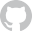
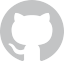

In [ ]:
import aiohttp


async def fetch_url(client: aiohttp.ClientSession, url: str) -> str:
    semaphore = asyncio.Semaphore(2)
    async with semaphore:
        print(f"Fetching {url}")
        async with client.get(url) as response:
            print(f"Finished fetching {url}")
            return f"{url}: {await response.text()}"


async def main(urls: list[str]) -> None:
    async with aiohttp.ClientSession() as client:
        tasks = [fetch_url(client, url) for url in urls]
        results = await asyncio.gather(*tasks)
        [print(result, "\n") for result in results]


await main([
    "https://www.example.com",
    "https://www.python.org",
    "https://www.asyncio.org",
    "https://www.aiohttp.org",
])

#### Event

An `Event` is a synchronization primitive that allows tasks to wait for a certain condition to be met before proceeding.\
An event maintains an internal flag that can be set or cleared.\
When a task waits for an event, it will block until the event's flag is set.\
This is useful for coordinating tasks that need to wait for a certain condition to be met before proceeding, such as waiting for a signal from another task or waiting for a certain amount of time to pass.
```python
import asyncio


async def waiter(event: asyncio.Event) -> None:
    print("⏳ Waiting for the event to be set...")
    await event.wait()
    print("🤩 Event has been set! Proceeding...")


async def setter(event: asyncio.Event) -> None:
    print("🔧 Setter is doing some work...")
    await asyncio.sleep(3)
    print("✅ Setter is setting the event.")
    event.set()


async def main() -> None:
    my_event = asyncio.Event()
    await asyncio.gather(waiter(my_event), setter(my_event))

asyncio.run(main())
```

In [2]:
import asyncio


async def waiter(event: asyncio.Event) -> None:
    print("⏳ Waiting for the event to be set...")
    await event.wait()
    print("🤩 Event has been set! Proceeding...")


async def setter(event: asyncio.Event) -> None:
    print("🔧 Setter is doing some work...")
    await asyncio.sleep(3)
    print("✅ Setter is setting the event.")
    event.set()


my_event = asyncio.Event()
await asyncio.gather(waiter(my_event), setter(my_event))

⏳ Waiting for the event to be set...
🔧 Setter is doing some work...
✅ Setter is setting the event.
🤩 Event has been set! Proceeding...


[None, None]

## Aiohttp

The `aiohttp` is an asynchronous HTTP client/server framework for Python.\
It provides a simple and efficient way to make HTTP requests and build web applications using asynchronous programming.\
In this section, we will explore the basics of using `aiohttp` to make HTTP requests and build a simple web server.

```python
import asyncio

from aiohttp import ClientSession


async def request_url() -> None:
    async with (
        ClientSession() as session,
        session.get("https://httpbin.org/headers") as response,
    ):
        print(f"Status: {response.status}")
        print(f"Content-type: {response.headers['content-type']}")
        html = await response.text()
        print(f"Body: {html[:100]}...")  # Print the first 100 characters of the response
        response = await response.read()
        print(f"Decode: {response.decode("utf-8")}")


asyncio.run(request_url())
```

In [ ]:
import asyncio

from aiohttp import ClientSession


async def request_url() -> None:
    async with (
        ClientSession() as session,
        session.get("https://httpbin.org/headers") as response,
    ):
        print(f"Status: {response.status}")
        print(f"Content-type: {response.headers['content-type']}")
        html = await response.text()
        print(
            f"Body: {html[:100]}..."
        )  # Print the first 100 characters of the response
        response = await response.read()
        print(f"Decode: {response.decode()}")


await request_url()

Status: 200
Content-type: application/json
Body: {
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate, zstd", 
    "Host": "h...
Decode: {
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate, zstd", 
    "Host": "httpbin.org", 
    "User-Agent": "Python/3.14 aiohttp/3.13.3", 
    "X-Amzn-Trace-Id": "Root=1-6990a381-0a4c18c6735f84324ea8e459"
  }
}



### Common errors in Aiohttp

`aiohttp` is the best library for web scraping in terms of time and effectiveness.

The most common errors we encounter when making HTTP requests are:
1. Server disconnected: This error occurs when we do not have enough time to establish a connection with the server.
2. Cannot connect to host www.psykhe.es:80 ssl:default [Semaphore timeout expired]: This error occurs when we do not have enough time to establish a connection with the server.
3. Cannot connect to host www.inpsiko.com:443 ssl:True [SSLCertVerificationError: (1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)')]: This error occurs when we do not have enough time to establish a connection with the server.
4. Status code 403: The server denies the connection, usually due to its speed.

### Solution to errors:
1. Use `requests_html` import `HTMLSession`
2. Use `requests_html` import `HTMLSession`
3. Use `requests_html` import `HTMLSession` and `urllib3`.\
a. What we need to do is ignore the SSL certification using the following parameter `session.get(r"https://www.centrocodex.com/",verify=False)` to be able to ignore the SSL certification.\
b. Then we use `urllib3` to disable the warnings that we are making HTTP requests without considering the SSL certification `urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)`
4. Use `requests_html` import `HTMLSession` and `urllib3`.\
a. What we need to do is ignore the SSL certification using the following parameter `session.get(r"https://www.centrocodex.com/",verify=False)` to be able to ignore the SSL certification.\
b. Then we use `urllib3` to disable the warnings that we are making HTTP requests without considering the SSL certification `urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)`

In these occasions is convenient to combine `requests_html` with `ThreadPool Executor` to be able to make more requests in less time and avoid the 403 error.

## HTTPX

`HTTPX` is a Python library that serves as an alternative to `requests` and is much faster, although the connection effectiveness with some servers is sometimes less effective, especially with applications that make concurrent requests.\
Its main features are:
1. Concurrency and performance: `HTTPX` is designed to be asynchronous and is compatible with the use of `async/await` in Python. This means it can perform multiple HTTP requests concurrently, which can significantly improve performance in applications that need to make many requests at once.
2. Compatibility with HTTP/1.1 and HTTP/2: `HTTPX` is compatible with both HTTP/1.1 and HTTP/2, allowing you to take advantage of the benefits of HTTP/2 when interacting with servers that support it.
3. Client and server interfaces: `HTTPX` provides both a client and a server interface, allowing you to build both high-performance client and server HTTP applications.
4. Customizable adapters: `HTTPX` is highly customizable and allows you to use adapters to control how requests are made, making it easy to integrate with specific systems and services.

Example:
```python
import asyncio

import httpx
```

In [ ]:
import asyncio

import httpx


async def fetch_data() -> dict | None:
    async with httpx.AsyncClient() as client:
        response = await client.get(
            "https://cdn.jsdelivr.net/npm/@fawazahmed0/currency-api@latest/v1/currencies.json",
        )
        print(f"Status: {response.status_code}")
        if response.status_code == 200:
            return response.json()
        print(f"Failed to fetch data: {response.status_code}")
        return None


result = await fetch_data()
if result:
    print("Fetched Data:")
    for key, value in result.items():
        print(f"{key}: {value}")

Status: 200
Fetched Data:
1inch: 1inch
aave: Aave
ada: Cardano
aed: Emirati Dirham
afn: Afghan Afghani
agix: SingularityNET
akt: Akash Network
algo: Algorand
all: Albanian Lek
amd: Armenian Dram
amp: Amp
ang: Dutch Guilder
aoa: Angolan Kwanza
ape: ApeCoin
apt: Aptos
ar: Arweave
arb: Arbitrum
ars: Argentine Peso
atom: Cosmos
ats: Austrian Schilling
aud: Australian Dollar
avax: Avalanche
awg: Aruban or Dutch Guilder
axs: Axie Infinity
azm: Azerbaijani Manat
azn: Azerbaijan Manat
bake: BakeryToken
bam: Bosnian Convertible Mark
bat: Basic Attention Token
bbd: Barbadian or Bajan Dollar
bch: Bitcoin Cash
bdt: Bangladeshi Taka
bef: Belgian Franc
bgn: Bulgarian Lev
bhd: Bahraini Dinar
bif: Burundian Franc
bmd: Bermudian Dollar
bnb: Binance Coin
bnd: Bruneian Dollar
bob: Bolivian Bolíviano
brl: Brazilian Real
bsd: Bahamian Dollar
bsv: Bitcoin SV
bsw: Biswap
btc: Bitcoin
btg: Bitcoin Gold
btn: Bhutanese Ngultrum
btt: BitTorrent
busd: Binance USD
bwp: Botswana Pula
byn: Belarusian Ruble
byr: Bela